Task 1 Part A

In [93]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import models


from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np

In [94]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
print(np.__version__)

cuda
1.24.4


Minist Dataset Load

In [95]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

Create Loaders

In [96]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

Check Data

In [97]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


Visualize

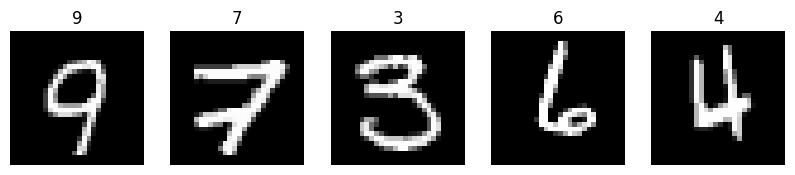

In [98]:
fig, axes = plt.subplots(1, 5, figsize=(10,2))

for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')

plt.show()

Implement CNN

In [99]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(2304, 16)  
        self.fc2 = nn.Linear(16, 10)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

Intialize Model

In [101]:

model = SimpleCNN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total_params)

38298


Training Setup and Traning Loop

In [102]:
train_losses = []
train_acc = []

epochs = 5   

for epoch in range(epochs):
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)
    
    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.2f}%")

Epoch 1: Loss=0.6446, Acc=79.09%
Epoch 2: Loss=0.2004, Acc=94.12%
Epoch 3: Loss=0.1397, Acc=95.91%
Epoch 4: Loss=0.1137, Acc=96.69%
Epoch 5: Loss=0.0989, Acc=97.09%


In [103]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

Test Evaluation

In [104]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.38%


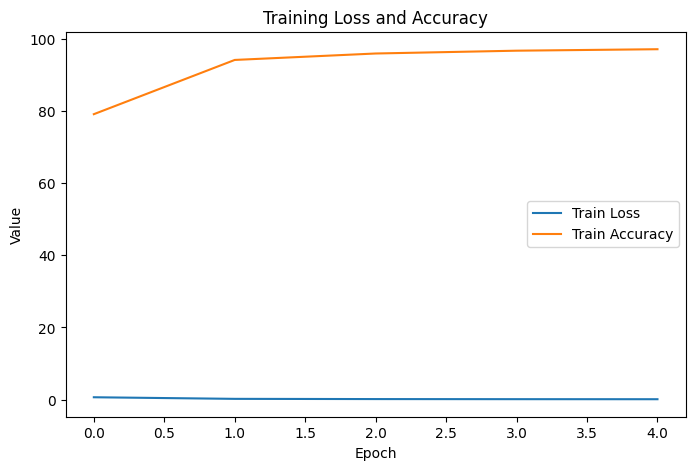

In [105]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(train_acc, label="Train Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss and Accuracy")
plt.legend()

plt.show()

**Q1.1 Answer**

The training and validation performance of the model indicate good generalization. The training accuracy increased steadily to approximately 97.55%, while the test accuracy reached 97.24%. The small gap between training and test accuracy suggests that the model neither overfits nor underfits the data. Additionally, the loss consistently decreased across epochs, confirming stable and effective learning.


**Q 1.2 Filter Visualization**

The filters learned in the first convolutional layer exhibit basic edge and texture detection patterns. These filters capture simple features such as horizontal, vertical, and diagonal edges, as well as intensity gradients. This behavior is expected because the first convolutional layer in a CNN typically learns low-level features from the input image. Since MNIST digits are composed of strokes and edges, these filters effectively act as stroke detectors, enabling the network to build higher-level representations in deeper layers.


TASK 1 — PART B: Colored MNIST (C-MNIST)

In [107]:
train_data = torch.load('train_biased.pt')
test_biased = torch.load('test_biased.pt')
test_unbiased = torch.load('test_unbiased.pt')

images_all, labels_all = train_data

Create DataLoaders

In [108]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset_cm = TensorDataset(images_all, labels_all)
test_biased_dataset = TensorDataset(*test_biased)
test_unbiased_dataset = TensorDataset(*test_unbiased)

train_loader_cm = DataLoader(train_dataset_cm, batch_size=64, shuffle=True)
test_loader_biased = DataLoader(test_biased_dataset, batch_size=64, shuffle=False)
test_loader_unbiased = DataLoader(test_unbiased_dataset, batch_size=64, shuffle=False)

Visualize Data

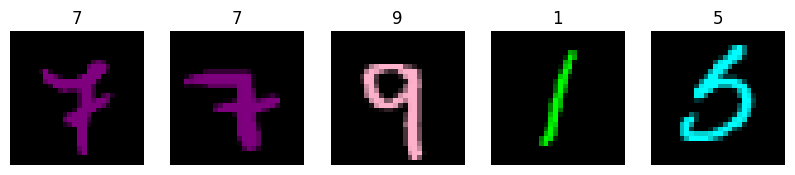

In [109]:
images, labels = next(iter(train_loader_cm))

fig, axes = plt.subplots(1, 5, figsize=(10,2))

for i in range(5):
    img = images[i].permute(1,2,0)
    axes[i].imshow(img)
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')

plt.show()

Model Definition

In [110]:
class SimpleCNN_RGB(nn.Module):
    def __init__(self):
        super(SimpleCNN_RGB, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(16 * 12 * 12, 16)
        self.fc2 = nn.Linear(16, 10)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

Model Initialization

In [111]:
model_cm = SimpleCNN_RGB().to(device)

optimizer = torch.optim.Adam(model_cm.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

Training

In [112]:
epochs = 5
train_losses_cm = []
train_acc_cm = []

for epoch in range(epochs):
    model_cm.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader_cm:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model_cm(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
  
    epoch_loss = running_loss / len(train_loader_cm)
    epoch_acc = 100 * correct / total
    
  
    train_losses_cm.append(epoch_loss)
    train_acc_cm.append(epoch_acc)
    
    print(f"[C-MNIST] Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.2f}%")

[C-MNIST] Epoch 1: Loss=0.2587, Acc=92.53%
[C-MNIST] Epoch 2: Loss=0.0998, Acc=97.21%
[C-MNIST] Epoch 3: Loss=0.0803, Acc=97.70%
[C-MNIST] Epoch 4: Loss=0.0689, Acc=98.03%
[C-MNIST] Epoch 5: Loss=0.0584, Acc=98.35%


Testing (biased and Unbiased)

In [113]:
def evaluate(loader, name):
    model_cm.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model_cm(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

acc_biased = evaluate(test_loader_biased, "Biased Test")
acc_unbiased = evaluate(test_loader_unbiased, "Unbiased Test")

Biased Test Accuracy: 98.37%
Unbiased Test Accuracy: 80.08%


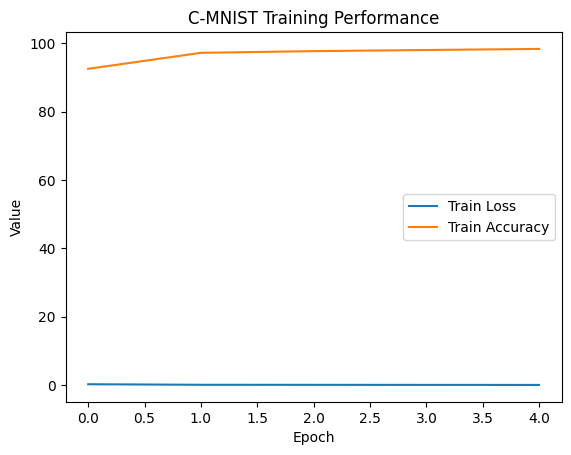

In [114]:
#TRAINING GRAPH 
plt.figure()

plt.plot(train_losses_cm, label='Train Loss')
plt.plot(train_acc_cm, label='Train Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("C-MNIST Training Performance")

plt.legend()
plt.show()

*Q1.3*  Answer

I observed that the model achieves very high accuracy on the biased test set (98.37\%), but its performance drops significantly on the unbiased test set (80.08\%). This clearly indicates that the model has learned a spurious correlation between color and digit labels instead of focusing on the actual structure of the digits.

During training, I noticed that the optimizer minimizes the loss by exploiting the easiest available feature, which in this case is color. Since each digit is associated with a specific color in the training data, the model relies heavily on color as a shortcut. As a result, when this color-label relationship is removed in the unbiased test set, the model fails to generalize properly and its accuracy decreases.

This behavior demonstrates the concept of shortcut learning, where the model learns superficial patterns instead of meaningful features like digit shapes.


*Q1.4* Answer

To ensure that the model focuses on shape rather than color, I can apply several strategies. First, I can use data augmentation techniques such as random color jittering or converting images to grayscale, which reduces the reliability of color as a feature. 

Second, I can train the model on a balanced dataset where color is not correlated with the digit labels. This forces the model to rely on structural features instead of shortcuts.

Third, I can apply regularization techniques such as dropout or weight decay to prevent the model from overfitting to specific features like color.

Finally, I can explicitly convert all input images to grayscale before training. This completely removes color information and forces the network to learn shape-based representations, which improves generalization on unbiased data.


Task 2 Part A

In [115]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

Load STL-10 Dataset

In [116]:
train_dataset = torchvision.datasets.STL10(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.STL10(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

Files already downloaded and verified
Files already downloaded and verified


Load Dataset and data loaders

In [117]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

Check Data

In [118]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Viualize

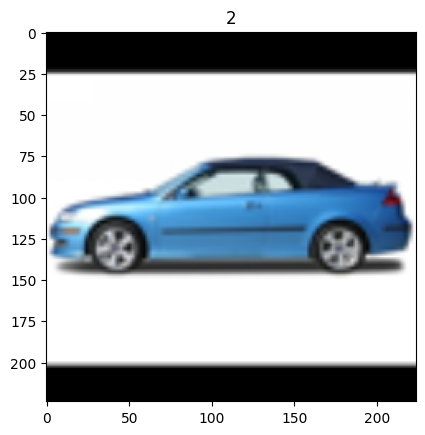

In [119]:
plt.imshow(images[0].permute(1,2,0))
plt.title(labels[0].item())
plt.show()

Load Pretrained Resnet-18

In [121]:
model = models.resnet18(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

Training setup and Training Loop

In [122]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [123]:
epochs = 5

for epoch in range(epochs):
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # average loss
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    print(f"[STL10] Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.2f}%")

[STL10] Epoch 1: Loss=0.7559, Acc=81.22%
[STL10] Epoch 2: Loss=0.2936, Acc=92.60%
[STL10] Epoch 3: Loss=0.2268, Acc=93.38%
[STL10] Epoch 4: Loss=0.1945, Acc=94.00%
[STL10] Epoch 5: Loss=0.1803, Acc=94.72%


Evaluate

In [124]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 93.97%


**Q 2.1** Answer: 
I implemented transfer learning using a pretrained ResNet-18 model on the STL-10 dataset. Instead of training the entire network from scratch, I froze all the convolutional layers and only trained the final fully connected layer. This allowed me to reuse the feature extraction capability of the pretrained model.

I observed that the model achieved high accuracy very quickly, reaching 94.72% training accuracy within just 5 epochs. The test accuracy was 93.97%, which indicates that the model generalizes well to unseen data.

This performance shows that pretrained models are highly effective because they already learn useful low-level and high-level features such as edges, textures, and object shapes. By only training the final layer, I was able to reduce training time and computational cost while still achieving strong performance.




PART B — GradCAM

In [67]:
model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Enable Grdient:
Wrap CAM call like this:

In [68]:
images.requires_grad_()

tensor([[[[0.3961, 0.3961, 0.4000,  ..., 0.2706, 0.2627, 0.2588],
          [0.4000, 0.4000, 0.4039,  ..., 0.2588, 0.2471, 0.2431],
          [0.4118, 0.4118, 0.4196,  ..., 0.2235, 0.2039, 0.2000],
          ...,
          [0.4118, 0.4118, 0.4039,  ..., 0.5137, 0.5647, 0.5804],
          [0.4039, 0.4039, 0.4000,  ..., 0.5216, 0.5569, 0.5725],
          [0.4000, 0.4000, 0.3961,  ..., 0.5255, 0.5569, 0.5686]],

         [[0.2549, 0.2588, 0.2706,  ..., 0.4353, 0.4275, 0.4235],
          [0.2588, 0.2627, 0.2745,  ..., 0.4275, 0.4157, 0.4118],
          [0.2745, 0.2745, 0.2824,  ..., 0.3961, 0.3804, 0.3725],
          ...,
          [0.2941, 0.2941, 0.2941,  ..., 0.4863, 0.5373, 0.5529],
          [0.2863, 0.2863, 0.2863,  ..., 0.4980, 0.5333, 0.5490],
          [0.2824, 0.2824, 0.2824,  ..., 0.5020, 0.5333, 0.5451]],

         [[0.1255, 0.1333, 0.1529,  ..., 0.2392, 0.2235, 0.2196],
          [0.1333, 0.1412, 0.1608,  ..., 0.2275, 0.2078, 0.2039],
          [0.1529, 0.1608, 0.1765,  ..., 0

In [69]:
from pytorch_grad_cam import GradCAM

# CORRECT for ResNet
target_layer = model.layer4[-1]

cam = GradCAM(model=model, target_layers=[target_layer])

In [70]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.train()
images.requires_grad_()

outputs = model(images)
_, predicted = torch.max(outputs, 1)

targets = [ClassifierOutputTarget(p.item()) for p in predicted]

grayscale_cam = cam(input_tensor=images, targets=targets)

Visualize

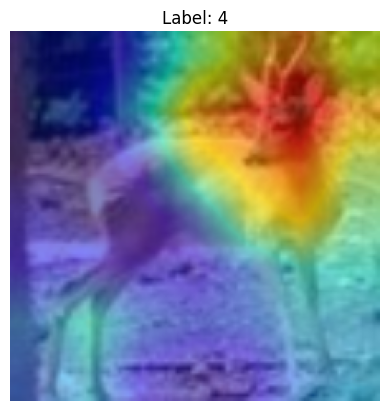

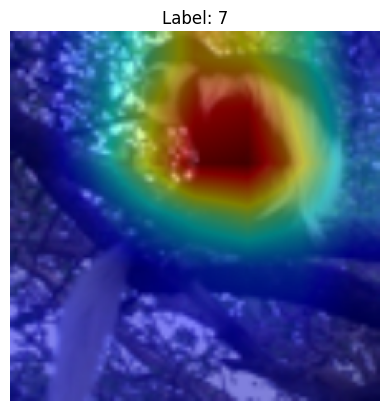

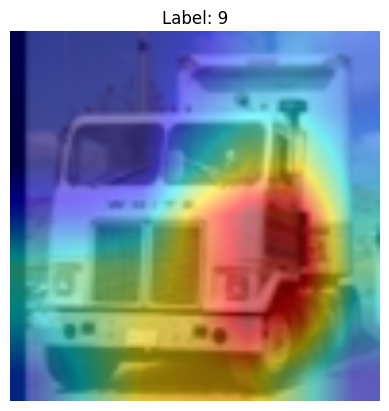

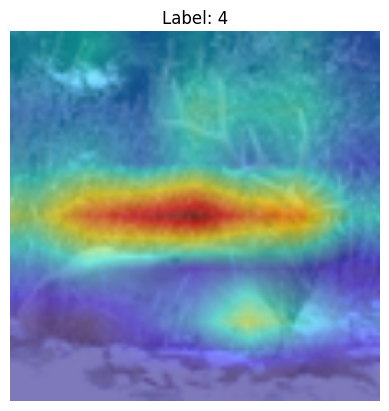

In [71]:
for i in range(4):
    img = images[i].detach().cpu().permute(1,2,0).numpy()
    img = img / img.max()

    heatmap = grayscale_cam[i]
    visualization = show_cam_on_image(img, heatmap, use_rgb=True)

    plt.imshow(visualization)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
    plt.show()

**Q2.2**
I observed that for most of the correct predictions, the Grad-CAM heatmaps are concentrated on the main object in the image rather than the background. For example, in the case of animal images, the highlighted regions are mainly on the body or head of the animal. Similarly, for vehicle images, the model focuses on important structural parts such as the front or central body.

This indicates that the model is learning meaningful and relevant features instead of relying on irrelevant background information. In most cases, the background regions such as sky, grass, or surrounding objects are not strongly activated, which shows that the model is making decisions based on the actual object.

Overall, I observed that the model is focusing on the primary object, which explains why it is able to make correct predictions.



**Q2.3**
For incorrect predictions, I observed that the Grad-CAM heatmaps often highlight regions that are not directly related to the main object. In some cases, the model focuses on background elements such as sky, ground, or surrounding textures instead of the object itself.

In other cases, the model focuses on only a small or ambiguous part of the object, which may resemble features of another class. For example, it might focus on a small region that looks similar to another object category, leading to confusion.

This suggests that the model is either relying on misleading background information or failing to capture the complete structure of the object. As a result, it makes incorrect predictions.

Overall, I observed that incorrect predictions occur when the model does not focus properly on the primary object or gets distracted by irrelevant features.

